In [1]:
import pandas as pd
import numpy as np

In [4]:
data = pd.read_csv('C:/Users/DELL/Downloads/titanic/test.csv')


In [5]:
print(data.head())

   PassengerId  Pclass                                          Name     Sex  \
0          892       3                              Kelly, Mr. James    male   
1          893       3              Wilkes, Mrs. James (Ellen Needs)  female   
2          894       2                     Myles, Mr. Thomas Francis    male   
3          895       3                              Wirz, Mr. Albert    male   
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female   

    Age  SibSp  Parch   Ticket     Fare Cabin Embarked  
0  34.5      0      0   330911   7.8292   NaN        Q  
1  47.0      1      0   363272   7.0000   NaN        S  
2  62.0      0      0   240276   9.6875   NaN        Q  
3  27.0      0      0   315154   8.6625   NaN        S  
4  22.0      1      1  3101298  12.2875   NaN        S  


In [6]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB
None


In [7]:
print(data.describe())

       PassengerId      Pclass         Age       SibSp       Parch        Fare
count   418.000000  418.000000  332.000000  418.000000  418.000000  417.000000
mean   1100.500000    2.265550   30.272590    0.447368    0.392344   35.627188
std     120.810458    0.841838   14.181209    0.896760    0.981429   55.907576
min     892.000000    1.000000    0.170000    0.000000    0.000000    0.000000
25%     996.250000    1.000000   21.000000    0.000000    0.000000    7.895800
50%    1100.500000    3.000000   27.000000    0.000000    0.000000   14.454200
75%    1204.750000    3.000000   39.000000    1.000000    0.000000   31.500000
max    1309.000000    3.000000   76.000000    8.000000    9.000000  512.329200


Maximum people are from 3rd class and 1st class passengers are few.
most of the people are alone with no sibling or parents.

In [10]:
print(data['Embarked'].value_counts())

Embarked
S    270
C    102
Q     46
Name: count, dtype: int64


In [11]:
print(data['Sex'].value_counts())

Sex
male      266
female    152
Name: count, dtype: int64


In [15]:
data.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [16]:
data = data.drop(columns ='Cabin')

In [17]:
data = data.dropna(subset = ['Fare'])

In [18]:
data['Age'] = data['Age'].fillna(data['Age'].median())


In [19]:
data.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


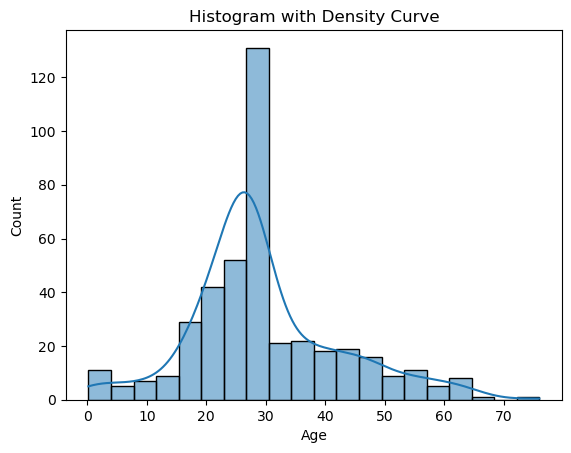

In [24]:
sns.histplot(data['Age'], bins=20, kde=True)
plt.title('Histogram with Density Curve')
plt.show()


Passengers are mostly middle aged around 20-30.

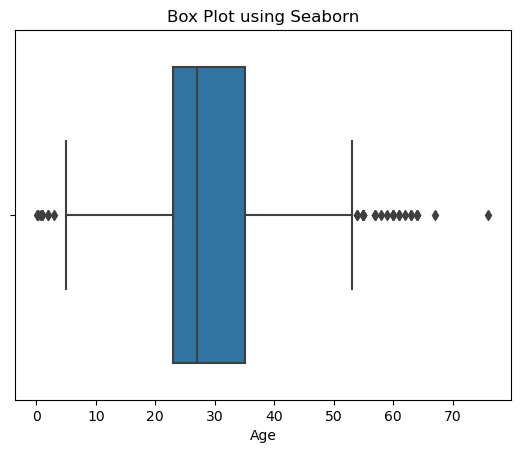

In [23]:
sns.boxplot(x=data['Age'])
plt.title('Box Plot using Seaborn')
plt.show()

outliers are shown among ages below 5years and above 55 years.

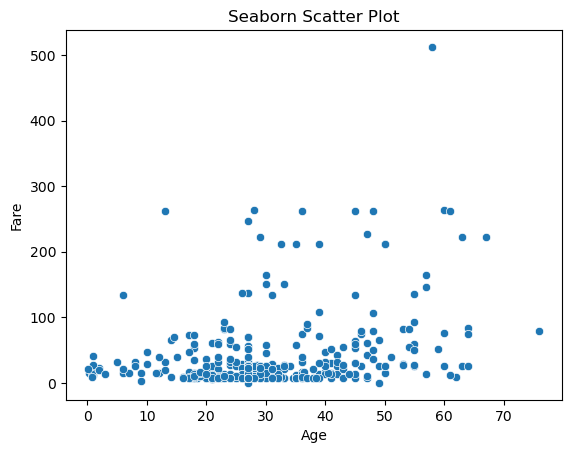

In [25]:
sns.scatterplot(x='Age', y='Fare', data=data)
plt.title('Seaborn Scatter Plot')
plt.show()


The more the age increses the fare of the ticket also increases.

In [32]:
selected_col= ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


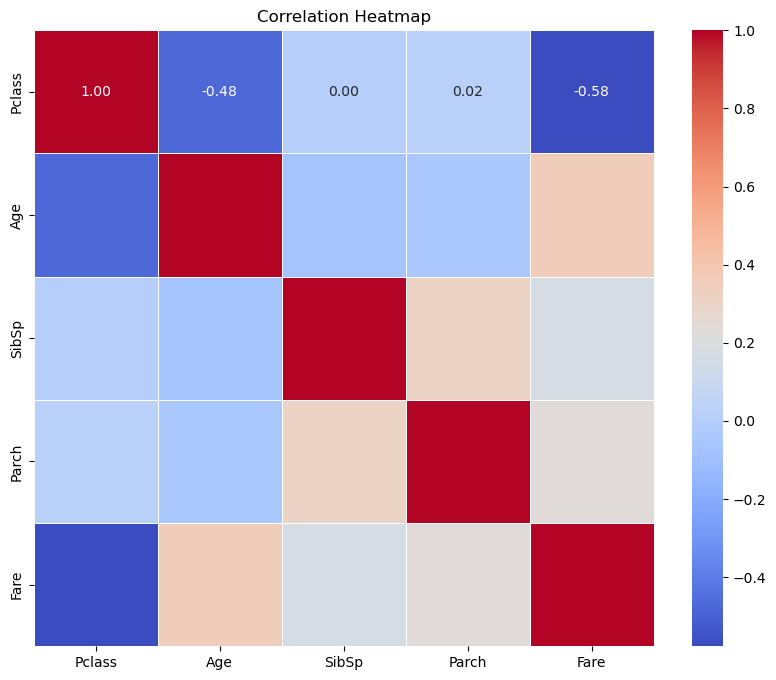

In [33]:
data_selected = data[selected_col]
corr_matrix = data_selected.dropna().corr()

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


young people paid less and older people paid more.

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

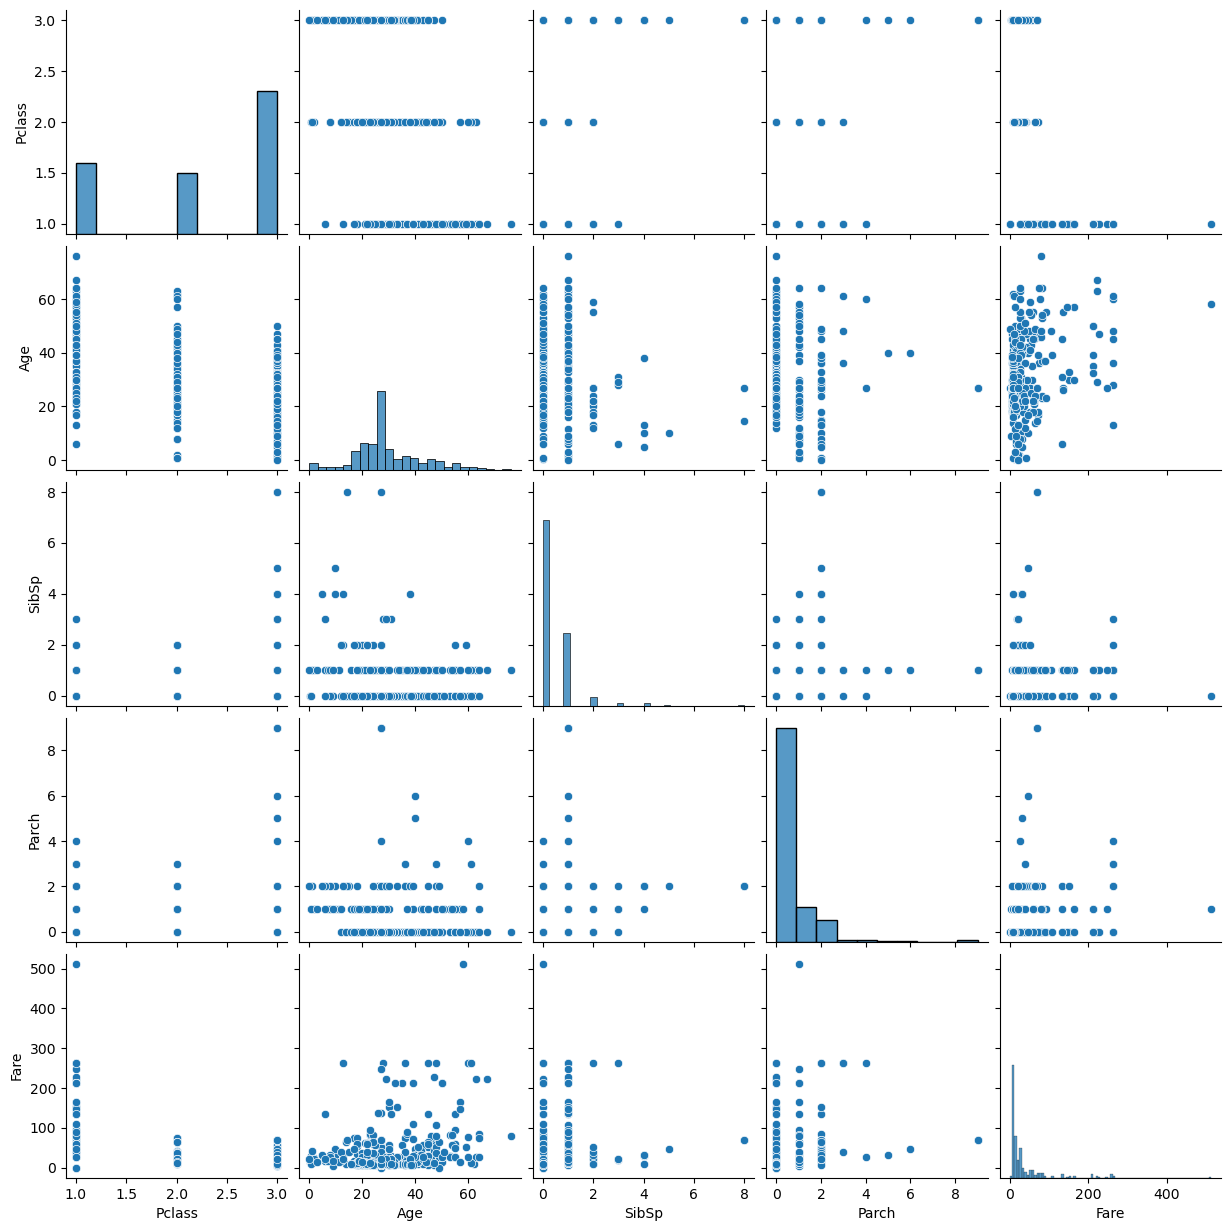

In [35]:

sns.pairplot(data[selected_col].dropna())
plt.show()


Overall Summary:

Passenger Class is a major differentiator.
1st class older and more price where as  3rd class younger and less price.
Most fares were low, but some were extremely high.
Both Siblings, spouse  and Parents child relations are zero for the majority.
Age distribution is centered around 30.
outliers are mostly infants and elder people.
Correlation plot show us the relation between all the categories.